## Entrenamiento de modelo de ML 

La idea es poder generar varios entrenamientos de 2 maneras de supervision (supervizado o no supervisado).  Veremos como se transforman y actua. 

## Entrenamiento no supervizado (IsolationForest)

se realiza un entrenamiento basico. 


In [2]:
import sys; sys.path.insert(0, '..')
import pandas as pd
import numpy as np

def cargar(bit):
    """Lee el CSV generado en el notebook 05 para un bit dado."""
    df = pd.read_csv(f'../data/processed/cca_o3_bit{bit:02d}_tasa05.csv',
                     parse_dates=['timestamp'])
    return df[df.received_value.notna()].copy()


def features(df, con_hora=True):
    """Construye la matriz de entrada del modelo.

    Solo received_value y hora. NUNCA original_value, bit, daño ni
    atacado: esas son verdad de campo, no informacion disponible en
    produccion.
    """
    X = pd.DataFrame(index=df.index)
    v = df.received_value
    X['valor_log'] = np.sign(v) * np.log1p(np.abs(v))
    if con_hora:
        X['hora_sin'] = np.sin(2*np.pi*df.hora/24)
        X['hora_cos'] = np.cos(2*np.pi*df.hora/24)
    return X

In [3]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_score, recall_score

res = []
for bit in range(13):
    df = cargar(bit)
    X = features(df, con_hora=True)
    y = df.atacado.values          # SOLO para evaluar, nunca para entrenar

    modelo = IsolationForest(contamination=0.05, random_state=42)
    pred = (modelo.fit_predict(X) == -1).astype(int)

    res.append({
        'bit': bit,
        'delta_ppb': 2**bit,
        'recall_%': round(recall_score(y, pred)*100, 1),
        'precision_%': round(precision_score(y, pred, zero_division=0)*100, 1),
        'fp': int(((pred==1) & (y==0)).sum()),
    })

pd.DataFrame(res)

,bit,delta_ppb,recall_%,precision_%,fp
0,0,1,5.1,5.0,323
1,1,2,11.4,11.2,302
2,2,4,6.9,6.8,316
3,3,8,7.8,7.8,308
4,4,16,12.3,12.1,297
5,5,32,18.6,18.2,278
6,6,64,43.7,45.1,178
7,7,128,79.9,78.5,73
8,8,256,89.8,90.4,32
9,9,512,100.0,98.2,6


In [4]:
from sklearn.ensemble import IsolationForest
from sklearn.tree import DecisionTreeClassifier
from src.attack.blind import generar_dataset
from src.ingest.rama import load_wide, to_long, chronological_split

# Dataset SIN ataques
long = to_long(load_wide('../data/raw/2025O3.xls'), 'O3')
cca = long[long.station == 'CCA'].reset_index(drop=True)
train, _ = chronological_split(cca)

limpio = generar_dataset(train, bit=5, tasa=0.0)
limpio = limpio[limpio.received_value.notna()]

X = features(limpio)
y = limpio.atacado.values

print(f"Filas: {len(X)}   ataques reales: {y.sum()}")

# No supervisado
iso = IsolationForest(contamination=0.05, random_state=42)
pred_iso = (iso.fit_predict(X) == -1).astype(int)
print(f"\nIsolationForest marcó: {pred_iso.sum()} mensajes")
print(f"  → todos son falsos positivos ({pred_iso.sum()/len(X)*100:.1f}% del total)")

# Supervisado: no se puede entrenar sin ejemplos positivos
print("\nSupervisado: no aplicable. Sin ataques en el conjunto de")
print("entrenamiento no hay clase positiva que aprender.")

Filas: 6788   ataques reales: 0

IsolationForest marcó: 340 mensajes
  → todos son falsos positivos (5.0% del total)

Supervisado: no aplicable. Sin ataques en el conjunto de
entrenamiento no hay clase positiva que aprender.


In [5]:
marcados = limpio[pred_iso == 1]

print("Falsos positivos por hora del día:")
print(marcados.hora.value_counts().sort_index().to_string())

print(f"\nValor de los marcados:  media {marcados.received_value.mean():.1f} ppb")
print(f"Valor de los NO marcados: media {limpio[pred_iso==0].received_value.mean():.1f} ppb")

Falsos positivos por hora del día:
hora
0     26
1      4
2     20
3     26
4     25
5      2
6     14
8     17
9      5
10     4
11     4
12    15
13    12
14    15
15    28
16    25
17     9
18    17
19    14
20    26
21    26
22     3
23     3

Valor de los marcados:  media 31.7 ppb
Valor de los NO marcados: media 36.1 ppb


In [6]:
perfil = limpio.groupby('hora')['received_value'].mean()

m = limpio[pred_iso == 1].copy()
nm = limpio[pred_iso == 0].copy()

m['desvio'] = m.received_value - m.hora.map(perfil)
nm['desvio'] = nm.received_value - nm.hora.map(perfil)

print(f"Desvío de los marcados:     {m.desvio.abs().mean():.1f} ppb")
print(f"Desvío de los NO marcados:  {nm.desvio.abs().mean():.1f} ppb")

Desvío de los marcados:     30.2 ppb
Desvío de los NO marcados:  11.6 ppb


In [7]:
limpio = limpio.copy()
limpio['pred'] = pred_iso
limpio['mes'] = limpio.timestamp.dt.month

tabla = limpio.groupby('mes').agg(
    total=('pred', 'size'),
    fp=('pred', 'sum'),
)
tabla['tasa_fp_%'] = (tabla.fp / tabla.total * 100).round(2)

print(tabla.to_string())

     total  fp  tasa_fp_%
mes                      
1      725  57       7.86
2      654  37       5.66
3      725  42       5.79
4      694  18       2.59
5      729  20       2.74
6      691  72      10.42
7      726   8       1.10
8      707  30       4.24
9      690  23       3.33
10     447  33       7.38


In [8]:
perfil_h = limpio.groupby('hora')['received_value'].mean()
limpio['desvio'] = (limpio.received_value - limpio.hora.map(perfil_h)).abs()

print(limpio.groupby('mes').agg(
    media_ppb=('received_value', 'mean'),
    std_ppb=('received_value', 'std'),
    desvio_medio=('desvio', 'mean'),
    tasa_fp=('pred', lambda s: s.mean()*100),
).round(2).to_string())

     media_ppb  std_ppb  desvio_medio  tasa_fp
mes                                           
1        29.72    27.45         12.30     7.86
2        36.00    30.97         10.60     5.66
3        40.29    33.60         11.09     5.79
4        47.43    31.67         14.60     2.59
5        45.99    31.60         15.30     2.74
6        27.27    26.20         16.24    10.42
7        34.60    27.02         10.71     1.10
8        34.06    29.61         10.06     4.24
9        31.58    29.39         11.47     3.33
10       29.67    27.39         13.51     7.38


## Falsos positivos sobre datos sin ataques

### Objetivo

Jaime solicitó verificar el comportamiento del detector sobre tráfico
legítimo: *«que te diga "alguien alteró" y tú digas "ni siquiera lo he
tocado"»*. Sin esa medición no es posible distinguir cuánto de lo
detectado en los experimentos anteriores es señal y cuánto es ruido.

Se generó un dataset con `tasa=0.0`: ningún mensaje alterado.

### Resultado global

**340 falsos positivos sobre 6,788 mensajes legítimos (5.01%).**

El valor no es casual. `contamination=0.05` obliga al IsolationForest a
marcar exactamente el 5% de las observaciones, exista o no un ataque. En
ausencia de ataques, ese 5% son necesariamente falsos positivos.

Esto constituye una limitación estructural del enfoque: el parámetro
`contamination` requiere conocer de antemano la tasa de anomalía, que en
producción es desconocida.

**El clasificador supervisado no es aplicable en este escenario.** Sin
ejemplos positivos en el conjunto de entrenamiento no existe clase que
aprender. Es una diferencia estructural entre ambos enfoques.

### Qué marca el detector

| | Desvío respecto al perfil horario |
|---|---|
| Mensajes marcados | 30.2 ppb |
| Mensajes no marcados | 11.6 ppb |

Los marcados se apartan casi tres veces más del valor típico de su hora.

Esto confirma que el modelo utiliza efectivamente las características
`hora_sin` y `hora_cos`: no marca valores extremos en términos absolutos
—de hecho la media de los marcados (31.7 ppb) es *inferior* a la de los
no marcados (36.1 ppb)— sino valores incongruentes con la hora del día.

### Hallazgo: la tasa de falsos positivos depende del mes

| Mes | Media (ppb) | σ | Tasa FP |
|---|---|---|---|
| Junio | 27.27 | 26.20 | **10.42%** |
| Enero | 29.72 | 27.45 | 7.86% |
| Octubre | 29.67 | 27.39 | 7.38% |
| Marzo | 40.29 | 33.60 | 5.79% |
| Febrero | 36.00 | 30.97 | 5.66% |
| Agosto | 34.06 | 29.61 | 4.24% |
| Septiembre | 31.58 | 29.39 | 3.33% |
| Mayo | 45.99 | 31.60 | 2.74% |
| Abril | 47.43 | 31.67 | 2.59% |
| Julio | 34.60 | 27.02 | **1.10%** |

*Sobre el conjunto de entrenamiento (enero a octubre). Noviembre y
diciembre quedan fuera por corresponder al conjunto de prueba.*

**La tasa varía por un factor de 9.5 entre el mes más alto y el más
bajo.**

### Interpretación

La tasa de falsos positivos **no correlaciona con la desviación estándar**
del mes: junio presenta la menor σ (26.20) y la mayor tasa de FP (10.42%).

Correlaciona con la **media**: los tres meses de menor concentración
media (junio 27.27, octubre 29.67, enero 29.72) figuran entre los cuatro
de mayor tasa de FP, mientras que los dos de mayor media (abril 47.43,
mayo 45.99) presentan las tasas más bajas.

La explicación es estructural. El IsolationForest aprende un perfil
horario **global**, promediado sobre todo el periodo, y no dispone de
información de estacionalidad. Un mes cuya distribución se desplaza
respecto a ese perfil produce desviaciones sistemáticas que el modelo
interpreta como anomalías individuales.

**El detector confunde variación estacional con manipulación.**

Julio constituye una excepción parcial (media intermedia, tasa mínima)
que no queda explicada por este mecanismo. Queda como pendiente.

### Implicaciones

1. **La evaluación sobre un único periodo no es representativa.** Con un
   corte cronológico 80/20, el conjunto de prueba corresponde a noviembre
   y diciembre. Dada la variación observada, el desempeño medido sobre
   ese periodo no puede extrapolarse al año completo. Esto justifica
   la validación cruzada temporal.

2. **Se requiere contexto temporal más allá de la hora del día.** Un
   perfil horario global es insuficiente: el modelo necesita capturar la
   tendencia local, sea mediante una característica de estacionalidad o
   mediante un modelo con memoria.

3. **El parámetro `contamination` es una limitación práctica.** Fija la
   tasa de detección de antemano, independientemente de que exista o no
   manipulación.

### Hipótesis descartada

Se consideró que el descenso de junio pudiera deberse a la reducción de
tráfico vehicular por periodo vacacional. El calendario escolar mexicano
sitúa las vacaciones entre mediados de julio y mediados de agosto: junio
es mes lectivo completo, y julio y agosto presentan concentraciones
medias **superiores** a junio. La hipótesis no se sostiene.

La explicación más plausible es el inicio de la temporada de lluvias en
el Valle de México, que reduce la formación fotoquímica por menor
radiación e incrementa la dispersión y el lavado atmosférico. La
verificación requeriría datos de la red meteorológica REDMET y queda
fuera del alcance de este trabajo: la causa física del mes atípico es
secundaria frente a su consecuencia sobre el detector.

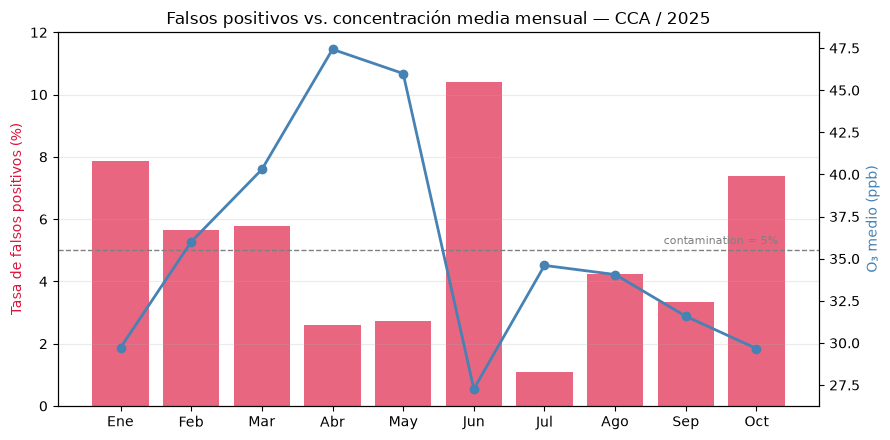

In [9]:
import matplotlib.pyplot as plt

t = tabla.copy()
meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct']

fig, ax1 = plt.subplots(figsize=(9, 4.5))

ax1.bar(range(len(t)), t['tasa_fp_%'], color='crimson', alpha=0.65,
        label='Tasa de falsos positivos')
ax1.axhline(5.0, ls='--', c='gray', lw=1)
ax1.text(9.3, 5.2, 'contamination = 5%', fontsize=8, c='gray', ha='right')
ax1.set_ylabel('Tasa de falsos positivos (%)', color='crimson')
ax1.set_xticks(range(len(t)))
ax1.set_xticklabels(meses)
ax1.set_ylim(0, 12)

ax2 = ax1.twinx()
medias = limpio.groupby('mes')['received_value'].mean()
ax2.plot(range(len(t)), medias.values, 'o-', color='steelblue', lw=2,
         label='O₃ medio del mes')
ax2.set_ylabel('O₃ medio (ppb)', color='steelblue')

ax1.set_title('Falsos positivos vs. concentración media mensual — CCA / 2025')
ax1.grid(alpha=0.25, axis='y')
plt.tight_layout()
plt.savefig('../docs/img/fp_por_mes.png', dpi=150)
plt.show()

In [10]:
res = []

# Sin ataques (ya lo tienes)
res.append({'escenario': 'sin ataques', 'fp': int(pred_iso.sum()),
            'ataques': 0, 'detectados': 0})

# Con ataques, por bit
for bit in [3, 5, 6, 9]:
    df = cargar(bit)
    X, y = features(df), df.atacado.values
    p = (IsolationForest(contamination=0.05, random_state=42)
         .fit_predict(X) == -1).astype(int)
    res.append({
        'escenario': f'bit {bit}',
        'fp': int(((p == 1) & (y == 0)).sum()),
        'ataques': int(y.sum()),
        'detectados': int(((p == 1) & (y == 1)).sum()),
    })

pd.DataFrame(res)

,escenario,fp,ataques,detectados
0,sin ataques,340,0,0
1,bit 3,308,334,26
2,bit 5,278,334,62
3,bit 6,178,334,146
4,bit 9,6,334,334


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, precision_score, fbeta_score

MODELOS = {
    'DecisionTree': lambda: DecisionTreeClassifier(random_state=42),
    'RandomForest': lambda: RandomForestClassifier(random_state=42),
}

res = []
for bit in [3, 4, 5, 6]:
    df = cargar(bit)
    X, y = features(df), df.atacado.values

    n = int(len(X) * 0.8)
    splits = {
        'cronologico': (X[:n], X[n:], y[:n], y[n:]),
        'estratificado': train_test_split(X, y, test_size=0.2,
                                          random_state=42, stratify=y),
    }

    for s_nombre, (Xtr, Xte, ytr, yte) in splits.items():
        for m_nombre, factory in MODELOS.items():
            m = factory()
            m.fit(Xtr, ytr)
            p = m.predict(Xte)
            res.append({
                'bit': bit,
                'split': s_nombre,
                'modelo': m_nombre,
                'ataques_test': int(yte.sum()),
                'recall_%': round(recall_score(yte, p, pos_label=1,
                                               zero_division=0)*100, 1),
                'precision_%': round(precision_score(yte, p, pos_label=1,
                                                     zero_division=0)*100, 1),
                'f2_%': round(fbeta_score(yte, p, beta=2, pos_label=1,
                                          zero_division=0)*100, 1),
            })

comp = pd.DataFrame(res)
tabla = comp.pivot_table(index=['bit', 'modelo'], columns='split',
                         values='recall_%').reset_index()
tabla.columns.name = None
tabla['delta_ppb'] = 2 ** tabla['bit']
tabla['diferencia'] = (tabla.estratificado - tabla.cronologico).round(1)

tabla = tabla[['bit', 'delta_ppb', 'modelo', 'cronologico',
               'estratificado', 'diferencia']]
tabla.columns = ['bit', 'Δ ppb', 'modelo', 'recall cronológico (%)',
                 'recall estratificado (%)', 'diferencia (pts)']
tabla

,bit,Δ ppb,modelo,recall cronológico (%),recall estratificado (%),diferencia (pts)
0,3,8,DecisionTree,4.3,7.5,3.2
1,3,8,RandomForest,4.3,7.5,3.2
2,4,16,DecisionTree,8.6,6.0,-2.6
3,4,16,RandomForest,8.6,4.5,-4.1
4,5,32,DecisionTree,41.4,28.4,-13.0
5,5,32,RandomForest,41.4,25.4,-16.0
6,6,64,DecisionTree,72.9,70.1,-2.8
7,6,64,RandomForest,72.9,70.1,-2.8


### Comparación de estrategias de partición

Recall sobre la clase atacada (`pos_label=1`), cuatro bits, dos modelos.

| bit | Δ ppb | modelo | Cronológico | Estratificado | Diferencia |
|---|---|---|---|---|---|
| 3 | 8 | DecisionTree | 4.3% | 7.5% | +3.2 |
| 3 | 8 | RandomForest | 4.3% | 7.5% | +3.2 |
| 4 | 16 | DecisionTree | 8.6% | 6.0% | −2.6 |
| 4 | 16 | RandomForest | 8.6% | 4.5% | −4.1 |
| 5 | 32 | DecisionTree | 41.4% | 28.4% | **−13.0** |
| 5 | 32 | RandomForest | 41.4% | 25.4% | **−16.0** |
| 6 | 64 | DecisionTree | 72.9% | 70.1% | −2.8 |
| 6 | 64 | RandomForest | 72.9% | 70.1% | −2.8 |

**El estratificado produce recalls inferiores en tres de los cuatro
bits.** El resultado es contrario a lo esperado: si barajar introdujera
fuga temporal, debería inflar el desempeño, no deprimirlo.

La diferencia se concentra en el bit 5 (−13 a −16 puntos), precisamente
la zona de transición donde el detector pasa de fallar a funcionar. En
los bits 3 y 6 la diferencia es marginal.

El bit 3 invierte el signo (+3.2), pero con recalls de 4-7% sobre ~70
casos positivos la diferencia corresponde a 2 o 3 aciertos: está dentro
del ruido.

**Interpretación (pendiente de verificación, V18):** el conjunto de
prueba cronológico corresponde a noviembre y diciembre. El análisis de
falsos positivos mostró que la tasa varía entre 1.10% y 10.42% según el
mes, con los meses de mayor concentración media presentando mejor
desempeño. Si noviembre y diciembre constituyen un periodo favorable, el
valor inflado sería el del split cronológico —no por fuga, sino por una
ventana de evaluación no representativa.

**Observación pendiente:** DecisionTree y RandomForest producen valores
idénticos en el split cronológico para los cuatro bits. Dado que son
algoritmos distintos, la coincidencia exacta requiere verificación:
podría indicar convergencia a la misma frontera de decisión con solo
tres características, o un problema en el experimento.

**Conclusión operativa:** ninguna de las dos particiones resuelve el
problema. El cronológico evalúa sobre un único periodo, no
representativo del año; el estratificado rompe el orden temporal. Se
adopta validación cruzada temporal (`TimeSeriesSplit`) como estrategia
definitiva.

## Escenario B.

In [14]:
from sklearn.ensemble import IsolationForest
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, precision_score, fbeta_score

df = pd.read_csv('../data/processed/cca_o3_bits345_tasa05.csv',
                 parse_dates=['timestamp'])
df = df[df.received_value.notna()].copy()

X, y = features(df), df.atacado.values
n = int(len(X) * 0.8)
Xtr, Xte, ytr, yte = X[:n], X[n:], y[:n], y[n:]

res = []

# No supervisado
iso = IsolationForest(contamination=0.05, random_state=42)
p_iso = (iso.fit_predict(X) == -1).astype(int)
res.append({'modelo': 'IsolationForest', 'conjunto': 'todo',
            'recall_%': round(recall_score(y, p_iso)*100, 1),
            'precision_%': round(precision_score(y, p_iso, zero_division=0)*100, 1),
            'f2_%': round(fbeta_score(y, p_iso, beta=2, zero_division=0)*100, 1)})

# Supervisados
for nombre, m in [('DecisionTree', DecisionTreeClassifier(random_state=42)),
                  ('RandomForest', RandomForestClassifier(random_state=42))]:
    m.fit(Xtr, ytr)
    p = m.predict(Xte)
    res.append({'modelo': nombre, 'conjunto': 'test',
                'recall_%': round(recall_score(yte, p, pos_label=1, zero_division=0)*100, 1),
                'precision_%': round(precision_score(yte, p, pos_label=1, zero_division=0)*100, 1),
                'f2_%': round(fbeta_score(yte, p, beta=2, pos_label=1, zero_division=0)*100, 1)})

pd.DataFrame(res)

,modelo,conjunto,recall_%,precision_%,f2_%
0,IsolationForest,todo,14.4,14.2,14.3
1,DecisionTree,test,11.4,33.3,13.2
2,RandomForest,test,12.9,36.0,14.8


## Conlcusiones 

Frente a un adversario que alterna entre los bits 3, 4 y 5, el desempeño del detector cae por debajo del promedio de los escenarios individuales: recall de 11.4% contra un promedio esperado de 18.1%. La degradación es más marcada respecto al bit 5 aislado, donde el mismo modelo alcanzaba 41.4%.

La variabilidad de la magnitud del ataque impide que el clasificador establezca un umbral estable. Un adversario que no fija su posición de ataque resulta considerablemente más difícil de detectar que uno que la mantiene constante, aun operando en el mismo rango de magnitudes.

Precision de 33-36% frente a una línea base de 5% (prevalencia de la clase). El detector aporta información, pero insuficiente: dos de cada tres alertas son falsas y nueve de cada diez ataques pasan.

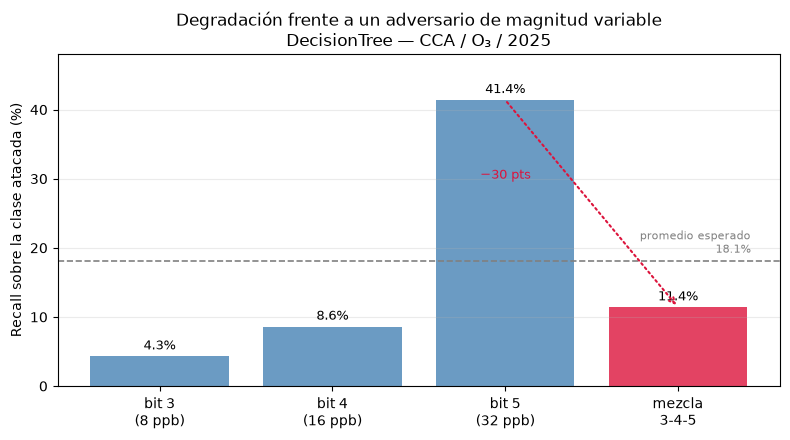

In [18]:
import matplotlib.pyplot as plt
import numpy as np

escenarios = ['bit 3\n(8 ppb)', 'bit 4\n(16 ppb)', 'bit 5\n(32 ppb)', 'mezcla\n3-4-5']
recall = [4.3, 8.6, 41.4, 11.4]
promedio_esperado = np.mean(recall[:3])

fig, ax = plt.subplots(figsize=(8, 4.5))

colores = ['steelblue']*3 + ['crimson']
barras = ax.bar(escenarios, recall, color=colores, alpha=0.8)

ax.axhline(promedio_esperado, ls='--', c='gray', lw=1.2)
ax.text(3.42, promedio_esperado + 1.2,
        f'promedio esperado\n{promedio_esperado:.1f}%',
        fontsize=8, c='gray', ha='right')

for b, v in zip(barras, recall):
    ax.text(b.get_x() + b.get_width()/2, v + 1, f'{v}%',
            ha='center', fontsize=9)

ax.annotate('', xy=(3, 11.4), xytext=(2, 41.4),
            arrowprops=dict(arrowstyle='->', color='crimson', lw=1.5, ls=':'))
ax.text(2.15, 30, '−30 pts', color='crimson', fontsize=9, ha='right')
ax.set_ylabel('Recall sobre la clase atacada (%)')
ax.set_title('Degradación frente a un adversario de magnitud variable\nDecisionTree — CCA / O₃ / 2025')
ax.set_ylim(0, 48)
ax.grid(alpha=0.25, axis='y')

plt.tight_layout()
plt.savefig('../docs/img/degradacion_mezcla.png', dpi=150)
plt.show()

## Adversario de magnitud variable (bits 3-4-5)

### Diseño

A solicitud del doc Jaime, se construyó un dataset donde cada mensaje
atacado recibe un bit elegido uniformemente al azar entre {3, 4, 5},
en lugar de fijar una única posición. Modela un adversario que opera
dentro de un rango de magnitudes (8 a 32 ppb) sin comprometerse con
una posición concreta.

Reparto obtenido: 100 ataques en bit 3, 111 en bit 4, 123 en bit 5.
Tasa de daño global: 18.6%.

### Resultado

| Modelo | Recall | Precision | F2 |
|---|---|---|---|
| IsolationForest | 14.4% | 14.2% | 14.3% |
| DecisionTree | 11.4% | 33.3% | 13.2% |
| RandomForest | 12.9% | 36.0% | 14.8% |

### Comparación con los escenarios de bit fijo

| Escenario | Recall (DecisionTree) |
|---|---|
| Solo bit 3 | 4.3% |
| Solo bit 4 | 8.6% |
| Solo bit 5 | 41.4% |
| **Mezcla 3-4-5** | **11.4%** |
| *Promedio esperado* | *18.1%* |

**La mezcla no promedia: degrada.** El recall obtenido (11.4%) queda
6.7 puntos por debajo del promedio de los tres escenarios individuales.

La caída es más pronunciada respecto al bit 5 aislado, donde el mismo
modelo alcanzaba 41.4%: el detector pierde más de dos tercios de su
capacidad para identificar exactamente los mismos ataques, por el solo
hecho de estar mezclados con otros de magnitud distinta.

### Interpretación

La variabilidad de la magnitud impide que el clasificador establezca un
umbral estable. Con bit fijo, todos los ataques producen el mismo
desplazamiento y la frontera de decisión es consistente. Con bit
variable, los ataques de 8 ppb quedan dentro de la variabilidad
legítima mientras los de 32 ppb la exceden, y no existe un único
criterio que los separe simultáneamente del tráfico normal.

**Un adversario que no fija su posición de ataque resulta
considerablemente más difícil de detectar que uno que la mantiene
constante, aun operando en el mismo rango de magnitudes.**

### Sobre la precision

Precision de 33-36%. La referencia correcta no es 50% —eso
correspondería a un problema balanceado— sino la prevalencia de la
clase: 5%. Un clasificador que marcara al azar obtendría 5% de
precision.

El detector aporta información (siete veces la línea base), pero
insuficiente para uso operativo: dos de cada tres alertas son falsas y
nueve de cada diez ataques pasan sin detección.

### Implicación

El resultado no indica una mala elección de clasificador: tres
algoritmos distintos convergen en el mismo rango. Indica que **la
evaluación de lecturas aisladas es insuficiente** para este modelo de
adversario.

Un detector que solo observa el valor recibido y la hora no dispone de
información para distinguir un desplazamiento de 8 ppb de la
variabilidad legítima. La información discriminante está en la
**secuencia**: la relación entre lecturas consecutivas y la
consistencia con el ciclo diurno esperado.

Esto constituye la justificación cuantitativa para la siguiente capa de
detección, basada en contexto temporal.